In [ ]:
# Notebook 03 — EDA y Visualización

**Reto 7 — Análisis de Datos No Estructurados y Redes Sociales**

## 🎯 Objetivo
Análisis exploratorio del corpus limpio: frecuencias, nubes de palabras,
patrones temporales, engagement, hashtags y menciones.

## 📌 Input
- `data/processed/tweets_nlp_YYYYMMDD.csv` (100k tweets limpios y lematizados)

## 📌 Output
- 7+ figuras en `outputs/figuras/`
- Conclusiones para el informe final

## 📊 Análisis incluidos
1. Estadísticas descriptivas
2. Top 30 palabras más frecuentes
3. Nube de palabras
4. Análisis temporal (tweets por día)
5. Distribución de engagement (likes, retweets)
6. Top hashtags
7. Top menciones
8. Bigramas y trigramas más comunes
9. (Opcional) Análisis por idioma

In [1]:
# === Imports ===
import re
from pathlib import Path
from datetime import datetime
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# === Configuración ===
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# === Rutas ===
def encontrar_raiz_proyecto():
    cwd = Path.cwd()
    for candidato in [cwd, cwd.parent, cwd.parent.parent, cwd.parent.parent.parent]:
        if (candidato / "requirements.txt").exists() and (candidato / "data").exists():
            return candidato
    return cwd.parent

BASE_DIR = encontrar_raiz_proyecto()
DATA_PROCESSED = BASE_DIR / "data" / "processed"
OUTPUTS_FIGURAS = BASE_DIR / "outputs" / "figuras"
OUTPUTS_FIGURAS.mkdir(parents=True, exist_ok=True)

print(f"📁 BASE_DIR: {BASE_DIR}")
print(f"📁 DATA_PROCESSED: {DATA_PROCESSED}")
print(f"📁 OUTPUTS_FIGURAS: {OUTPUTS_FIGURAS}")

📁 BASE_DIR: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados
📁 DATA_PROCESSED: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\data\processed
📁 OUTPUTS_FIGURAS: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\outputs\figuras


In [2]:
# ============================================
# Cargar corpus limpio del Notebook 02
# ============================================

archivos = sorted(
    DATA_PROCESSED.glob("tweets_nlp_*.csv"),
    key=lambda x: x.stat().st_mtime,
    reverse=True
)

if not archivos:
    # Fallback
    archivos = sorted(
        DATA_PROCESSED.glob("tweets_limpios_*.csv"),
        key=lambda x: x.stat().st_mtime,
        reverse=True
    )

RUTA = archivos[0]
print(f"📂 Cargando: {RUTA.name}")

df = pd.read_csv(RUTA, encoding="utf-8-sig")

# Convertir tokens y lemas de string a lista
if "tokens" in df.columns and isinstance(df["tokens"].iloc[0], str):
    df["tokens"] = df["tokens"].apply(eval)
if "lemas" in df.columns and isinstance(df["lemas"].iloc[0], str):
    df["lemas"] = df["lemas"].apply(eval)

# Convertir fecha
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(f"✅ Shape inicial: {df.shape}")
print(f"📋 Columnas: {list(df.columns)}")
print(f"\n📊 Tipos:")
print(df.dtypes)
display(df.head(3))

📂 Cargando: tweets_nlp_20260920.csv
✅ Shape inicial: (100000, 7)
📋 Columnas: ['date', 'username', 'texto_limpio', 'tokens', 'lemas', 'like_count', 'retweet_count']

📊 Tipos:
date             datetime64[us, UTC]
username                         str
texto_limpio                     str
tokens                        object
lemas                         object
like_count                   float64
retweet_count                float64
dtype: object


,date,username,texto_limpio,tokens,lemas,like_count,retweet_count
0,2023-03-29 22:58:21+00:00,RealProfitPros,free ai marketing and automation tools strategies and collaboration launching new week chatgpt,"[free, marketing, automation, tools, strategies, collaboration, launching, week]","[freir, marketing, automation, tools, strategies, collaboration, launching, week]",0.0,0.0
1,2023-03-29 22:58:18+00:00,AmyLouWho321,chat gpt says it s,"[chat, says]","[chat, says]",0.0,0.0
2,2023-03-29 22:57:53+00:00,yjleon1976,chat with any pdf check out how this new ai quickly answers questions from your pdfs perfect for students researchers and other curious minds research chatpdf chatgpt,"[chat, pdf, check, quickly, answers, questions, pdfs, perfect, students, researchers, curious, minds, research, chatpdf]","[chat, pdf, check, quickly, answer, questions, pdfs, perfect, students, researchers, curious, minds, research, chatpdf]",0.0,0.0


In [3]:
# ============================================
# Filtrar tweets muy cortos (spam/basura)
# ============================================

n_inicial = len(df)

# Calcular longitud del texto limpio
df["_len_limpio"] = df["texto_limpio"].astype(str).str.len()

# Filtrar: >= 20 caracteres
df = df[df["_len_limpio"] >= 20].copy()

n_final = len(df)
n_filtrados = n_inicial - n_final

print(f"📊 Tweets iniciales:  {n_inicial:,}")
print(f"🗑️  Filtrados (<20):  {n_filtrados:,} ({n_filtrados/n_inicial*100:.1f}%)")
print(f"✅ Tweets finales:    {n_final:,}")

# Resetear índice
df = df.reset_index(drop=True)

# Verificar
print(f"\n📏 Longitud mínima: {df['_len_limpio'].min()}")
print(f"📏 Longitud máxima: {df['_len_limpio'].max()}")
print(f"📏 Longitud media:  {df['_len_limpio'].mean():.1f}")

📊 Tweets iniciales:  100,000
🗑️  Filtrados (<20):  4,042 (4.0%)
✅ Tweets finales:    95,958

📏 Longitud mínima: 20.0
📏 Longitud máxima: 291.0
📏 Longitud media:  141.9


In [4]:
# ============================================
# Estadísticas descriptivas
# ============================================
print("=" * 60)
print("📊 ESTADÍSTICAS DESCRIPTIVAS DEL CORPUS")
print("=" * 60)

print(f"\n📄 Total de tweets:     {len(df):,}")
print(f"👥 Usuarios únicos:     {df['username'].nunique():,}")
print(f"📅 Rango de fechas:     {df['date'].min().date()} → {df['date'].max().date()}")
print(f"📅 Días cubiertos:      {df['date'].dt.date.nunique()}")

print(f"\n❤️  Likes:")
print(f"   Total:  {df['like_count'].sum():,.0f}")
print(f"   Media:  {df['like_count'].mean():.2f}")
print(f"   Máximo: {df['like_count'].max():,.0f}")

print(f"\n🔁 Retweets:")
print(f"   Total:  {df['retweet_count'].sum():,.0f}")
print(f"   Media:  {df['retweet_count'].mean():.2f}")
print(f"   Máximo: {df['retweet_count'].max():,.0f}")

# Tokens/lemas
total_tokens = df["tokens"].str.len().sum()
total_lemas = df["lemas"].str.len().sum()
print(f"\n🔤 Total tokens:        {total_tokens:,}")
print(f"🌿 Total lemas:         {total_lemas:,}")

vocab_tokens = set()
vocab_lemas = set()
for t in df["tokens"]:
    vocab_tokens.update(t)
for l in df["lemas"]:
    vocab_lemas.update(l)

print(f"📚 Vocabulario tokens:  {len(vocab_tokens):,}")
print(f"📚 Vocabulario lemas:   {len(vocab_lemas):,}")

# Top usuarios con más tweets
print(f"\n👑 Top 5 usuarios más activos:")
top_users = df["username"].value_counts().head(5)
for user, count in top_users.items():
    print(f"   @{user}: {count:,} tweets")

📊 ESTADÍSTICAS DESCRIPTIVAS DEL CORPUS

📄 Total de tweets:     95,958
👥 Usuarios únicos:     59,983
📅 Rango de fechas:     2023-03-16 → 2023-03-29
📅 Días cubiertos:      14

❤️  Likes:
   Total:  788,830
   Media:  8.22
   Máximo: 28,049

🔁 Retweets:
   Total:  149,991
   Media:  1.56
   Máximo: 8,060

🔤 Total tokens:        1,148,260
🌿 Total lemas:         1,145,953
📚 Vocabulario tokens:  62,692
📚 Vocabulario lemas:   65,132

👑 Top 5 usuarios más activos:
   @bitone_great: 548 tweets
   @Inkstall: 290 tweets
   @richardkimphd: 224 tweets
   @saadnajeebsaad: 201 tweets
   @JimyTuits: 201 tweets


🔢 Calculando frecuencias...

📊 Top 30 palabras más frecuentes:
    1. chat                   32,152
    2. google                  4,636
    3. artificialintelligence    4,192
    4. technology              3,873
    5. time                    3,838
    6. asked                   3,670
    7. write                   3,585
    8. bard                    3,452
    9. world                   3,155
   10. could                   2,959
   11. help                    2,927
   12. nft                     2,921
   13. would                   2,863
   14. work                    2,800
   15. tech                    2,799
   16. ask                     2,767
   17. language                2,741
   18. better                  2,724
   19. chatbot                 2,681
   20. microsoft               2,635
   21. read                    2,608
   22. peoplir                 2,594
   23. intelligence            2,457
   24. way                     2,445
   25. bing                    2,428
   26. mod

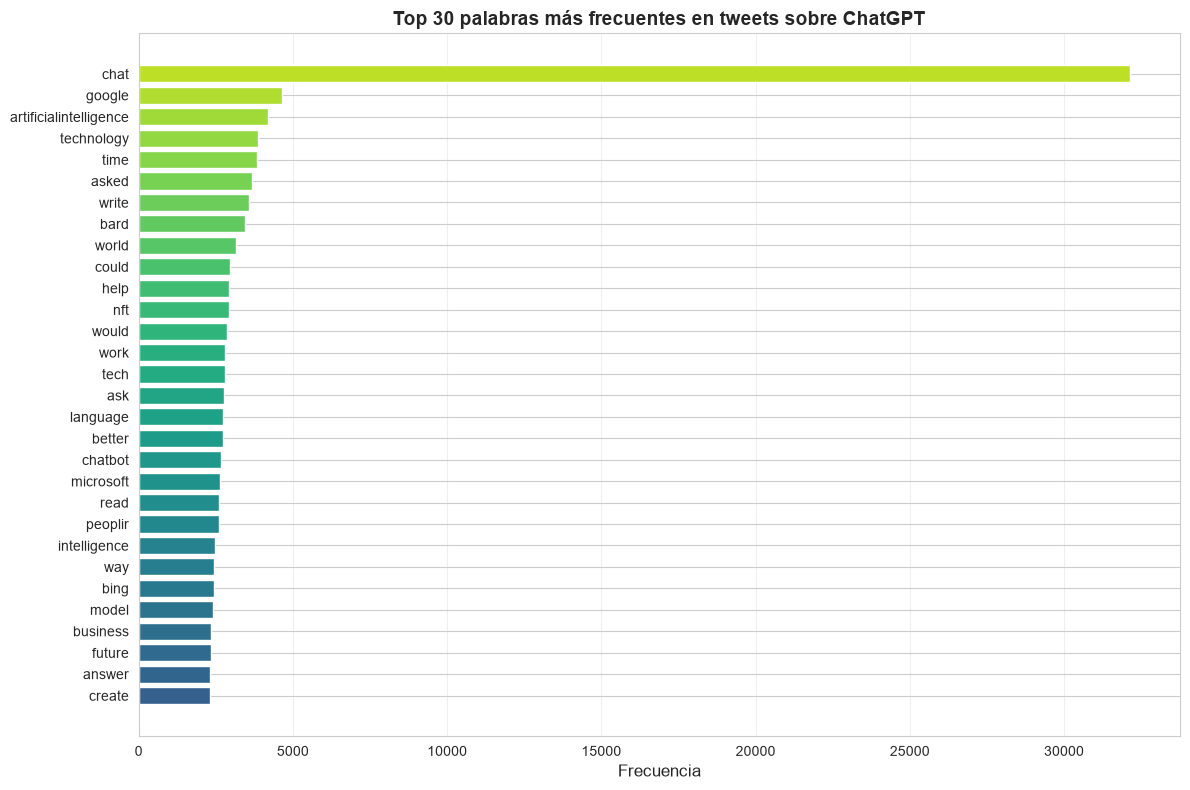


✅ Guardado: outputs/figuras/top_30_palabras.png


In [5]:
# ============================================
# Top 30 palabras más frecuentes (lemas)
# ============================================
print("🔢 Calculando frecuencias...")

# Contar palabras (usando lemas)
todas_palabras = []
for lemas in df["lemas"]:
    todas_palabras.extend(lemas)

conteo = Counter(todas_palabras)
top_30 = conteo.most_common(30)

print(f"\n📊 Top 30 palabras más frecuentes:")
for i, (palabra, freq) in enumerate(top_30, 1):
    print(f"   {i:2d}. {palabra:20s} {freq:>8,}")

# Visualización
fig, ax = plt.subplots(figsize=(12, 8))
palabras = [p[0] for p in top_30][::-1]
frecuencias = [p[1] for p in top_30][::-1]

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(palabras)))
ax.barh(palabras, frecuencias, color=colors)
ax.set_xlabel("Frecuencia", fontsize=12)
ax.set_title("Top 30 palabras más frecuentes en tweets sobre ChatGPT",
             fontsize=14, fontweight="bold")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURAS / "top_30_palabras.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ Guardado: outputs/figuras/top_30_palabras.png")

☁️  Generando nube de palabras...


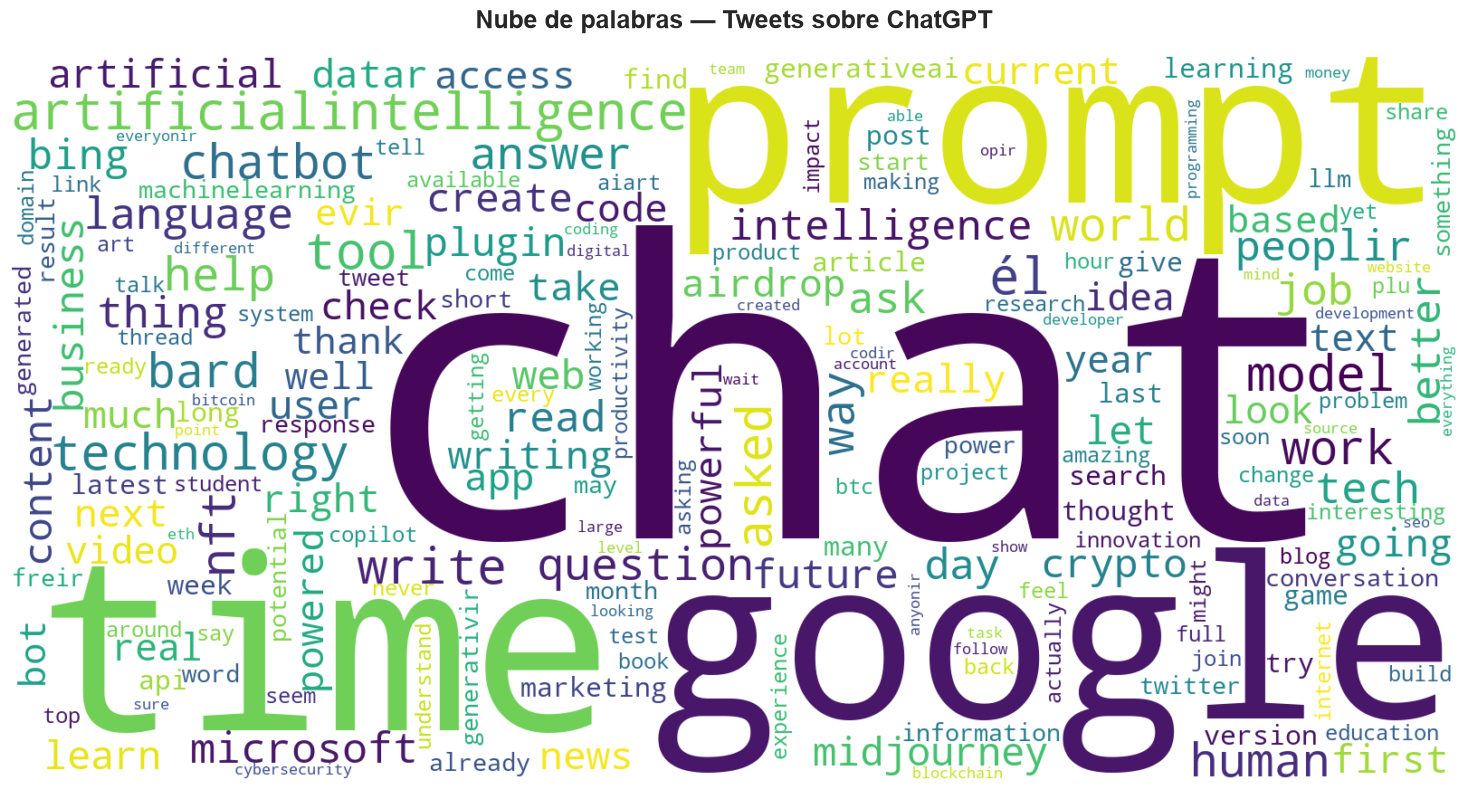

✅ Guardado: outputs/figuras/wordcloud_chatgpt.png


In [6]:
# ============================================
# Nube de palabras
# ============================================
print("☁️  Generando nube de palabras...")

# Unir todos los lemas
texto_completo = " ".join(todas_palabras)

# Generar nube
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    colormap="viridis",
    max_words=200,
    min_font_size=10,
    collocations=False,
).generate(texto_completo)

# Visualizar
fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(wordcloud, interpolation="bilinear")
ax.axis("off")
ax.set_title("Nube de palabras — Tweets sobre ChatGPT",
             fontsize=18, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURAS / "wordcloud_chatgpt.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ Guardado: outputs/figuras/wordcloud_chatgpt.png")

📅 Analizando patrones temporales...


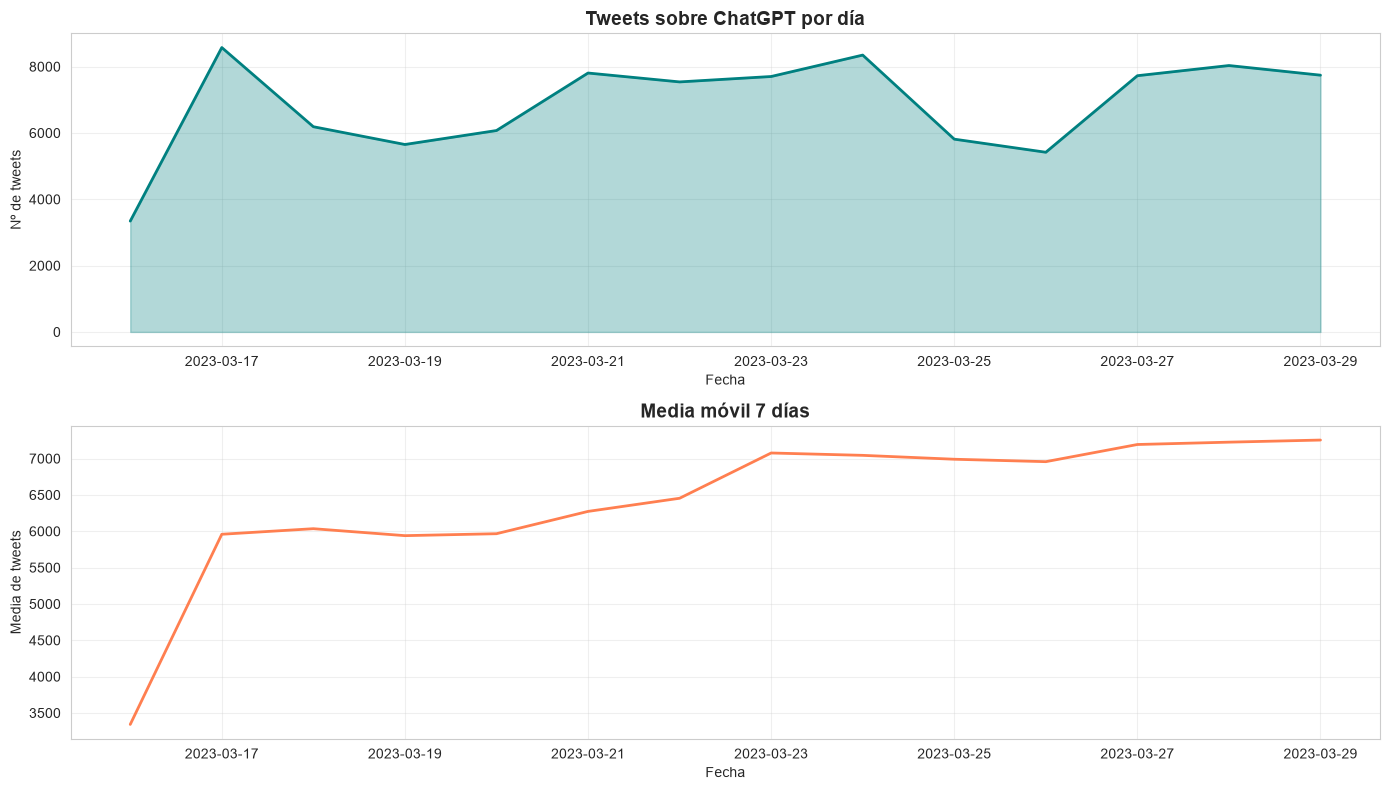


📊 Estadísticas temporales:
   Media por día:   6854
   Mediana:         7620
   Máximo:          8,575 el 2023-03-17
   Mínimo:          3,342 el 2023-03-16

✅ Guardado: outputs/figuras/tweets_por_dia.png


In [7]:
# ============================================
# Análisis temporal
# ============================================
print("📅 Analizando patrones temporales...")

# Tweets por día
tweets_por_dia = df.groupby(df["date"].dt.date).size()

# Visualización
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Serie completa
axes[0].plot(tweets_por_dia.index, tweets_por_dia.values, color="teal", linewidth=2)
axes[0].fill_between(tweets_por_dia.index, tweets_por_dia.values, alpha=0.3, color="teal")
axes[0].set_title("Tweets sobre ChatGPT por día", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Nº de tweets")
axes[0].grid(alpha=0.3)

# Media móvil 7 días
media_movil = tweets_por_dia.rolling(window=7, min_periods=1).mean()
axes[1].plot(media_movil.index, media_movil.values, color="coral", linewidth=2)
axes[1].set_title("Media móvil 7 días", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Media de tweets")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURAS / "tweets_por_dia.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n📊 Estadísticas temporales:")
print(f"   Media por día:   {tweets_por_dia.mean():.0f}")
print(f"   Mediana:         {tweets_por_dia.median():.0f}")
print(f"   Máximo:          {tweets_por_dia.max():,} el {tweets_por_dia.idxmax()}")
print(f"   Mínimo:          {tweets_por_dia.min():,} el {tweets_por_dia.idxmin()}")

print(f"\n✅ Guardado: outputs/figuras/tweets_por_dia.png")

📊 Analizando engagement...


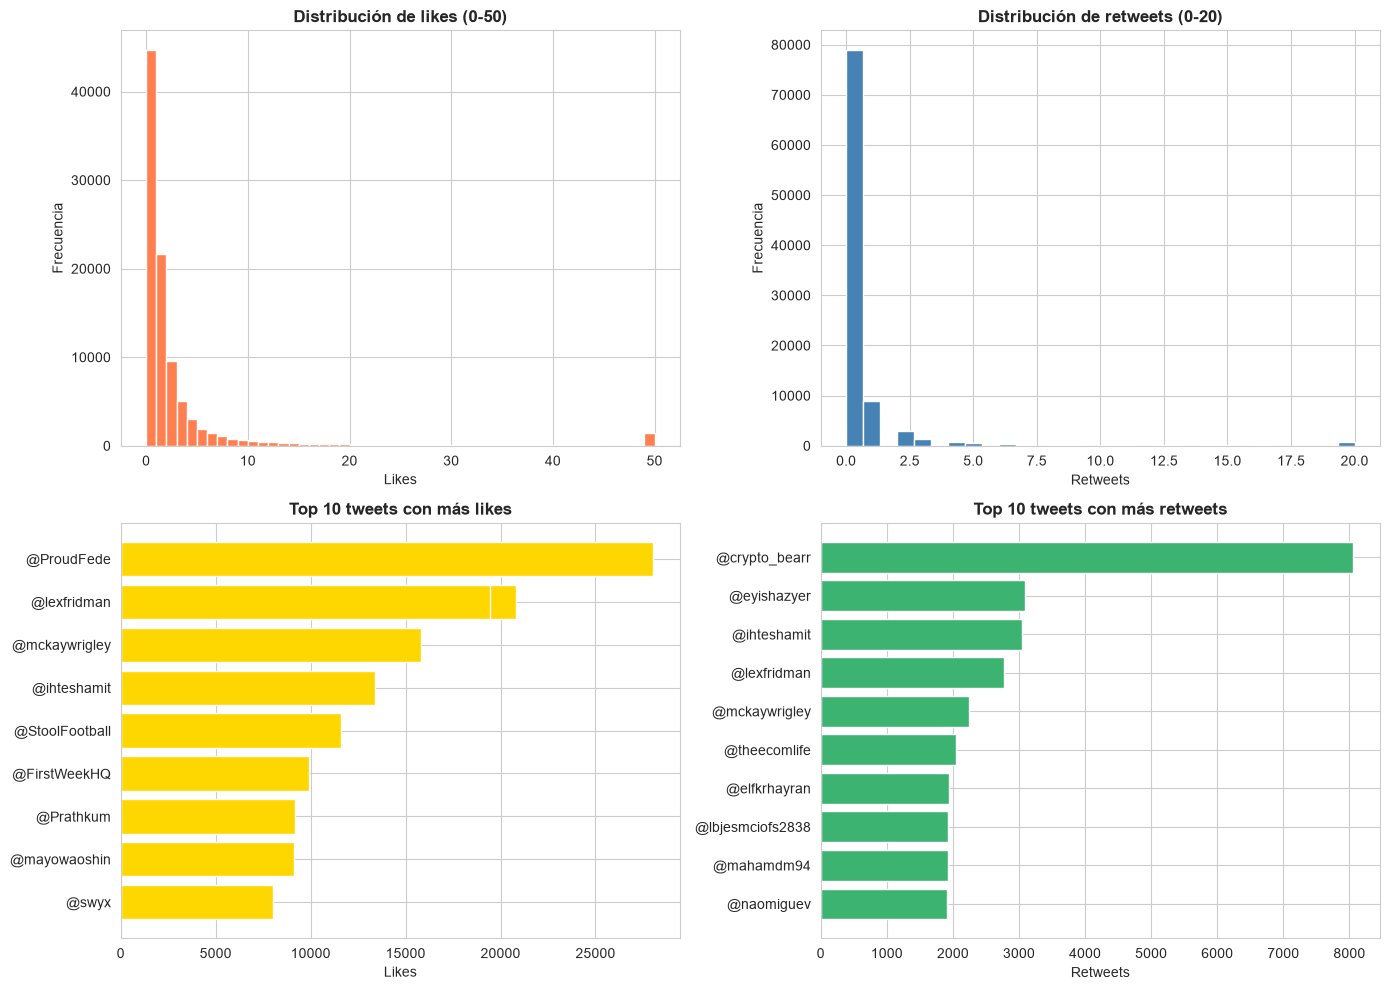


📊 Estadísticas engagement:

❤️  Likes:
   Media:   8.22
   Mediana: 1
   Máximo:  28,049
   Tweets con 0 likes: 44,666

🔁 Retweets:
   Media:   1.56
   Mediana: 0
   Máximo:  8,060
   Tweets con 0 RT:    78,893

✅ Guardado: outputs/figuras/engagement_distribucion.png


In [8]:
# ============================================
# Distribución de engagement
# ============================================
print("📊 Analizando engagement...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Likes (recortado)
df["like_count"].clip(upper=50).hist(bins=50, ax=axes[0, 0], color="coral", edgecolor="white")
axes[0, 0].set_title("Distribución de likes (0-50)", fontweight="bold")
axes[0, 0].set_xlabel("Likes")
axes[0, 0].set_ylabel("Frecuencia")

# Retweets (recortado)
df["retweet_count"].clip(upper=20).hist(bins=30, ax=axes[0, 1], color="steelblue", edgecolor="white")
axes[0, 1].set_title("Distribución de retweets (0-20)", fontweight="bold")
axes[0, 1].set_xlabel("Retweets")
axes[0, 1].set_ylabel("Frecuencia")

# Top 10 tweets con más likes
top_likes = df.nlargest(10, "like_count")[["username", "like_count", "texto_limpio"]]
labels = [f"@{u[:15]}" for u in top_likes["username"]]
axes[1, 0].barh(labels, top_likes["like_count"], color="gold")
axes[1, 0].set_title("Top 10 tweets con más likes", fontweight="bold")
axes[1, 0].set_xlabel("Likes")
axes[1, 0].invert_yaxis()

# Top 10 tweets con más retweets
top_rt = df.nlargest(10, "retweet_count")[["username", "retweet_count"]]
labels = [f"@{u[:15]}" for u in top_rt["username"]]
axes[1, 1].barh(labels, top_rt["retweet_count"], color="mediumseagreen")
axes[1, 1].set_title("Top 10 tweets con más retweets", fontweight="bold")
axes[1, 1].set_xlabel("Retweets")
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURAS / "engagement_distribucion.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n📊 Estadísticas engagement:")
print(f"\n❤️  Likes:")
print(f"   Media:   {df['like_count'].mean():.2f}")
print(f"   Mediana: {df['like_count'].median():.0f}")
print(f"   Máximo:  {df['like_count'].max():,.0f}")
print(f"   Tweets con 0 likes: {(df['like_count'] == 0).sum():,}")

print(f"\n🔁 Retweets:")
print(f"   Media:   {df['retweet_count'].mean():.2f}")
print(f"   Mediana: {df['retweet_count'].median():.0f}")
print(f"   Máximo:  {df['retweet_count'].max():,.0f}")
print(f"   Tweets con 0 RT:    {(df['retweet_count'] == 0).sum():,}")

print(f"\n✅ Guardado: outputs/figuras/engagement_distribucion.png")

In [9]:
# ============================================
# Top hashtags
# ============================================
print("#️⃣  Extrayendo hashtags del contenido original...")

# Necesitamos el contenido original
archivos_raw = sorted(
    DATA_PROCESSED.glob("tweets_limpios_*.csv"),
    key=lambda x: x.stat().st_mtime,
    reverse=True
)

if archivos_raw:
    df_orig = pd.read_csv(archivos_raw[0], encoding="utf-8-sig", usecols=["content"])
    # Alinear con df filtrado (por índice original)
    # Como hemos reseteado el índice, mejor reextraer del propio df
    pass

# Extraer hashtags del texto limpio no tiene sentido (los quitamos)
# Así que extraemos del content original cargado en df si existe
if "content" in df.columns:
    hashtags = []
    for texto in df["content"].astype(str):
        hashtags.extend(re.findall(r"#(\w+)", texto.lower()))
    
    conteo_hashtags = Counter(hashtags)
    top_20 = conteo_hashtags.most_common(20)
    
    print(f"\n📊 Top 20 hashtags:")
    for i, (tag, freq) in enumerate(top_20, 1):
        print(f"   {i:2d}. #{tag:25s} {freq:>6,}")
    
    # Visualización
    fig, ax = plt.subplots(figsize=(12, 8))
    tags = [f"#{t[0]}" for t in top_20][::-1]
    freqs = [t[1] for t in top_20][::-1]
    
    ax.barh(tags, freqs, color="mediumpurple")
    ax.set_xlabel("Frecuencia", fontsize=12)
    ax.set_title("Top 20 hashtags en tweets sobre ChatGPT",
                 fontsize=14, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUTS_FIGURAS / "top_hashtags.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"\n✅ Guardado: outputs/figuras/top_hashtags.png")
else:
    print("⚠️ Columna 'content' no disponible. Cargar desde tweets_limpios_*.csv")

#️⃣  Extrayendo hashtags del contenido original...
⚠️ Columna 'content' no disponible. Cargar desde tweets_limpios_*.csv


In [10]:
# ============================================
# Top menciones (@usuario)
# ============================================
print("@️⃣  Extrayendo menciones...")

if "content" in df.columns:
    menciones = []
    for texto in df["content"].astype(str):
        menciones.extend(re.findall(r"@(\w+)", texto.lower()))
    
    conteo_menciones = Counter(menciones)
    top_20_menc = conteo_menciones.most_common(20)
    
    print(f"\n📊 Top 20 usuarios mencionados:")
    for i, (user, freq) in enumerate(top_20_menc, 1):
        print(f"   {i:2d}. @{user:25s} {freq:>6,}")
    
    # Visualización
    fig, ax = plt.subplots(figsize=(12, 8))
    users = [f"@{m[0]}" for m in top_20_menc][::-1]
    freqs = [m[1] for m in top_20_menc][::-1]
    
    ax.barh(users, freqs, color="dodgerblue")
    ax.set_xlabel("Frecuencia", fontsize=12)
    ax.set_title("Top 20 usuarios más mencionados", fontsize=14, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUTS_FIGURAS / "top_menciones.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"\n✅ Guardado: outputs/figuras/top_menciones.png")
else:
    print("⚠️ Columna 'content' no disponible")

@️⃣  Extrayendo menciones...
⚠️ Columna 'content' no disponible


🔗 Calculando bigramas...

📊 Top 20 bigramas:
    1. artificial intelligence                   1,893
    2. airdrop nft                               1,609
    3. times powerful                              991
    4. powerful current                            980
    5. current airdrop                             972
    6. asked chat                                  961
    7. chat write                                  863
    8. language model                              824
    9. ask chat                                    736
   10. google bard                                 695
   11. bing chat                                   615
   12. language models                             601
   13. last prizar                                 545
   14. prizar rsi                                  545
   15. rsi powered                                 545
   16. large language                              510
   17. social medio                                449
   18. sam altman   

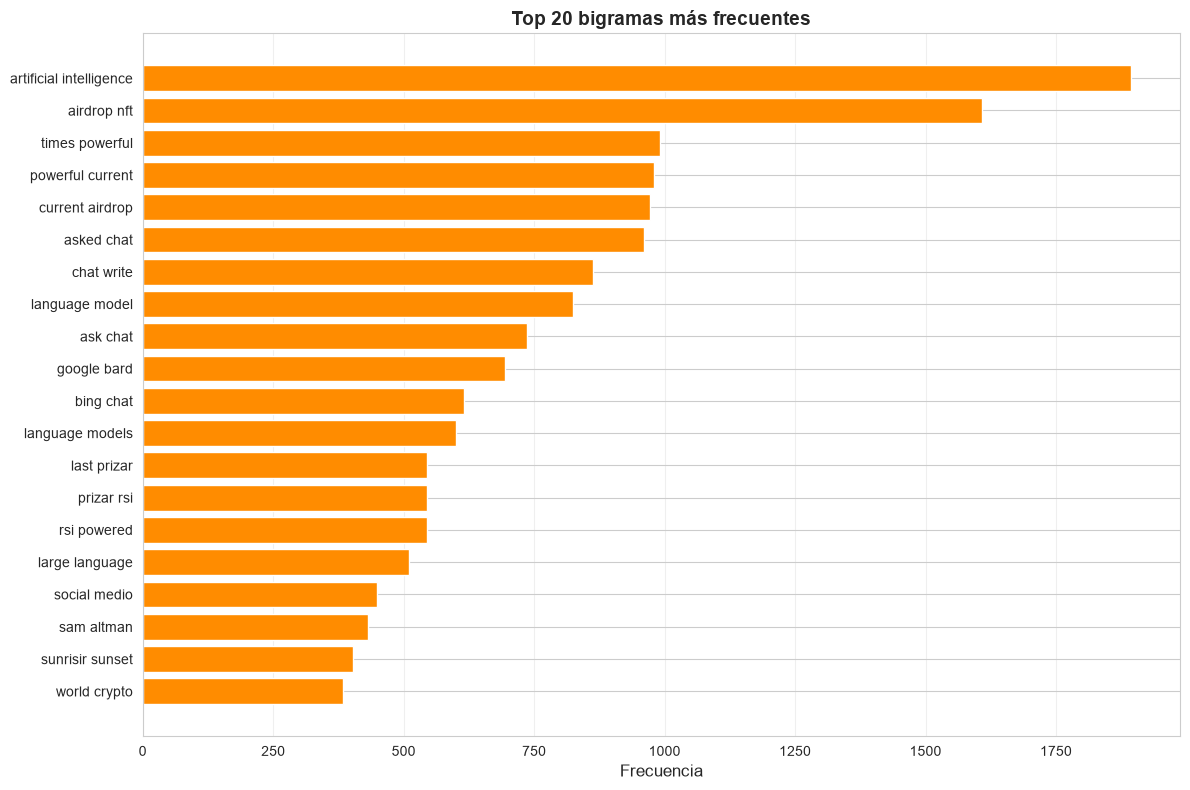


✅ Guardado: outputs/figuras/top_bigramas.png


In [11]:
# ============================================
# Bigramas (pares de palabras)
# ============================================
print("🔗 Calculando bigramas...")

bigramas = []
for lemas in df["lemas"]:
    for i in range(len(lemas) - 1):
        bigramas.append(f"{lemas[i]} {lemas[i+1]}")

conteo_bigr = Counter(bigramas)
top_20_bigr = conteo_bigr.most_common(20)

print(f"\n📊 Top 20 bigramas:")
for i, (bigr, freq) in enumerate(top_20_bigr, 1):
    print(f"   {i:2d}. {bigr:40s} {freq:>6,}")

# Visualización
fig, ax = plt.subplots(figsize=(12, 8))
bigrs = [b[0] for b in top_20_bigr][::-1]
freqs = [b[1] for b in top_20_bigr][::-1]

ax.barh(bigrs, freqs, color="darkorange")
ax.set_xlabel("Frecuencia", fontsize=12)
ax.set_title("Top 20 bigramas más frecuentes", fontsize=14, fontweight="bold")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURAS / "top_bigramas.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ Guardado: outputs/figuras/top_bigramas.png")

🔗 Calculando trigramas...

📊 Top 15 trigramas:
    1. times powerful current                                980
    2. powerful current airdrop                              972
    3. current airdrop nft                                   972
    4. last prizar rsi                                       545
    5. prizar rsi powered                                    545
    6. ready enter world                                     371
    7. enter world crypto                                    371
    8. triple productivity ready                             370
    9. productivity ready enter                              370
   10. world crypto uniswap                                  370
   11. crypto uniswap dextool                                370
   12. large language models                                 354
   13. recommendation short ticker                           311
   14. binance spot recommendation                           309
   15. time interval min                   

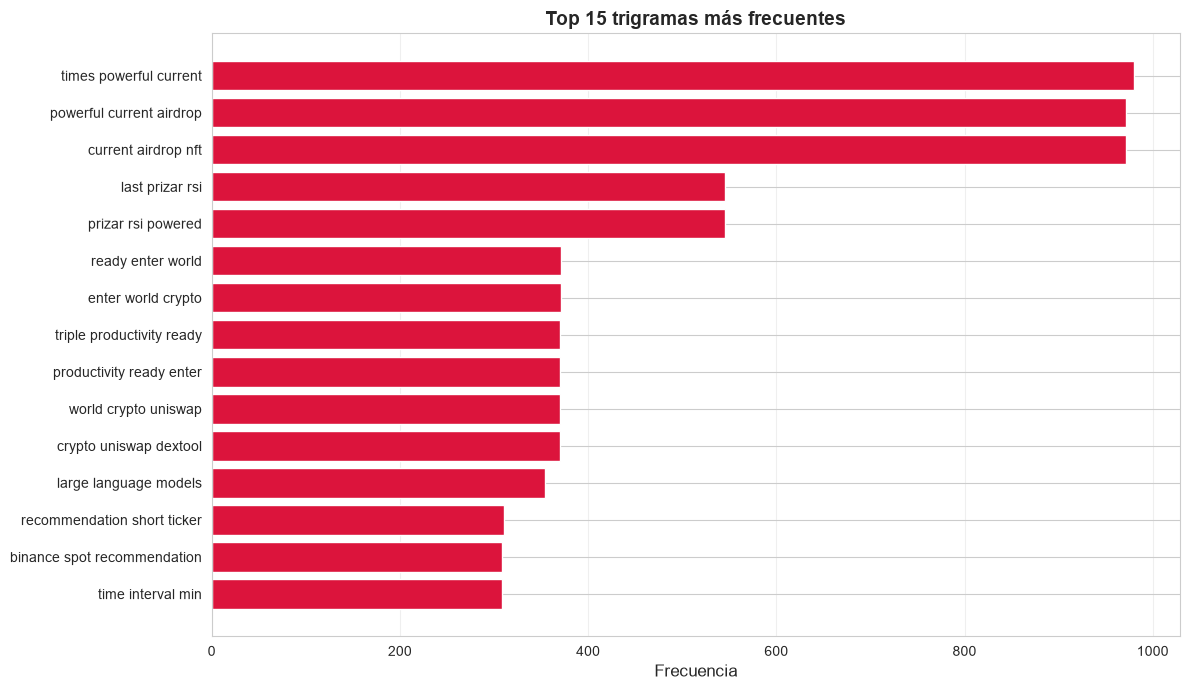


✅ Guardado: outputs/figuras/top_trigramas.png


In [12]:
# ============================================
# Trigramas (tripletes de palabras)
# ============================================
print("🔗 Calculando trigramas...")

trigramas = []
for lemas in df["lemas"]:
    for i in range(len(lemas) - 2):
        trigramas.append(f"{lemas[i]} {lemas[i+1]} {lemas[i+2]}")

conteo_trigr = Counter(trigramas)
top_15_trigr = conteo_trigr.most_common(15)

print(f"\n📊 Top 15 trigramas:")
for i, (trigr, freq) in enumerate(top_15_trigr, 1):
    print(f"   {i:2d}. {trigr:50s} {freq:>6,}")

# Visualización
fig, ax = plt.subplots(figsize=(12, 7))
trigrs = [t[0] for t in top_15_trigr][::-1]
freqs = [t[1] for t in top_15_trigr][::-1]

ax.barh(trigrs, freqs, color="crimson")
ax.set_xlabel("Frecuencia", fontsize=12)
ax.set_title("Top 15 trigramas más frecuentes", fontsize=14, fontweight="bold")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURAS / "top_trigramas.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ Guardado: outputs/figuras/top_trigramas.png")

🌍 Detectando idioma (heurística)...

📊 Distribución estimada de idiomas:
idioma_est
inglés     70873
otro       25033
español       52
Name: count, dtype: int64


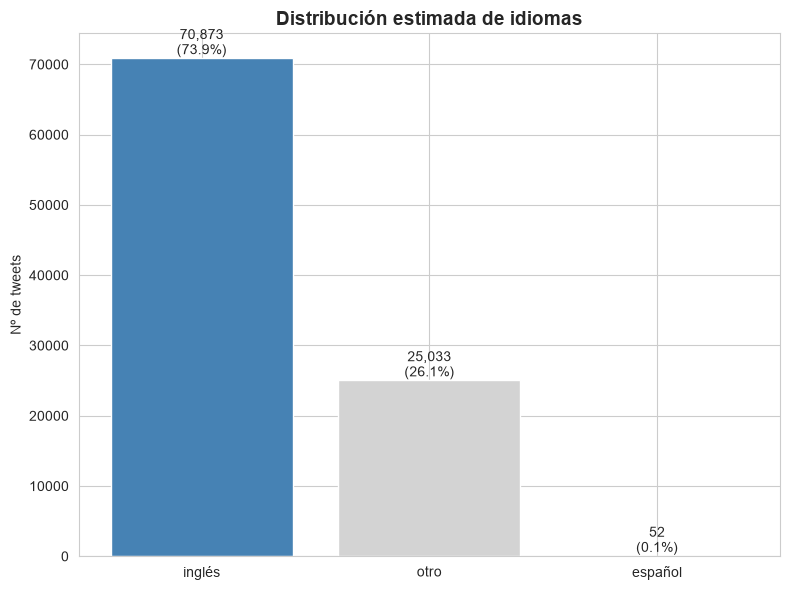


✅ Guardado: outputs/figuras/distribucion_idiomas.png


In [13]:
# ============================================
# Análisis por idioma (heurística simple)
# ============================================
print("🌍 Detectando idioma (heurística)...")

def detectar_idioma(texto):
    """Heurística simple basada en caracteres del español."""
    if not isinstance(texto, str):
        return "otro"
    texto_lower = texto.lower()
    
    # Palabras típicas
    palabras_es = [" que ", " de ", " la ", " el ", " en ", " es ", " un ",
                   " con ", " para ", " los ", " las ", " por ", " una ", " del "]
    palabras_en = [" the ", " and ", " is ", " to ", " of ", " in ", " for ",
                   " that ", " with ", " this ", " are ", " on ", " it "]
    
    cont_es = sum(1 for p in palabras_es if p in texto_lower)
    cont_en = sum(1 for p in palabras_en if p in texto_lower)
    
    # Acentos del español
    tiene_acentos = bool(re.search(r"[áéíóúñ¿¡]", texto_lower))
    
    if cont_es > cont_en and (cont_es >= 2 or tiene_acentos):
        return "español"
    elif cont_en > cont_es and cont_en >= 2:
        return "inglés"
    else:
        return "otro"

# Aplicar (solo si tenemos el texto limpio)
df["idioma_est"] = df["texto_limpio"].apply(detectar_idioma)

print(f"\n📊 Distribución estimada de idiomas:")
print(df["idioma_est"].value_counts())

# Visualización
fig, ax = plt.subplots(figsize=(8, 6))
colores = {"español": "gold", "inglés": "steelblue", "otro": "lightgray"}
conteo_idiomas = df["idioma_est"].value_counts()
bars = ax.bar(
    conteo_idiomas.index,
    conteo_idiomas.values,
    color=[colores.get(x, "gray") for x in conteo_idiomas.index]
)
ax.set_title("Distribución estimada de idiomas", fontsize=14, fontweight="bold")
ax.set_ylabel("Nº de tweets")

# Añadir etiquetas
for bar, val in zip(bars, conteo_idiomas.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{val:,}\n({val/len(df)*100:.1f}%)",
            ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURAS / "distribucion_idiomas.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ Guardado: outputs/figuras/distribucion_idiomas.png")

🌍 Analizando top palabras por idioma...


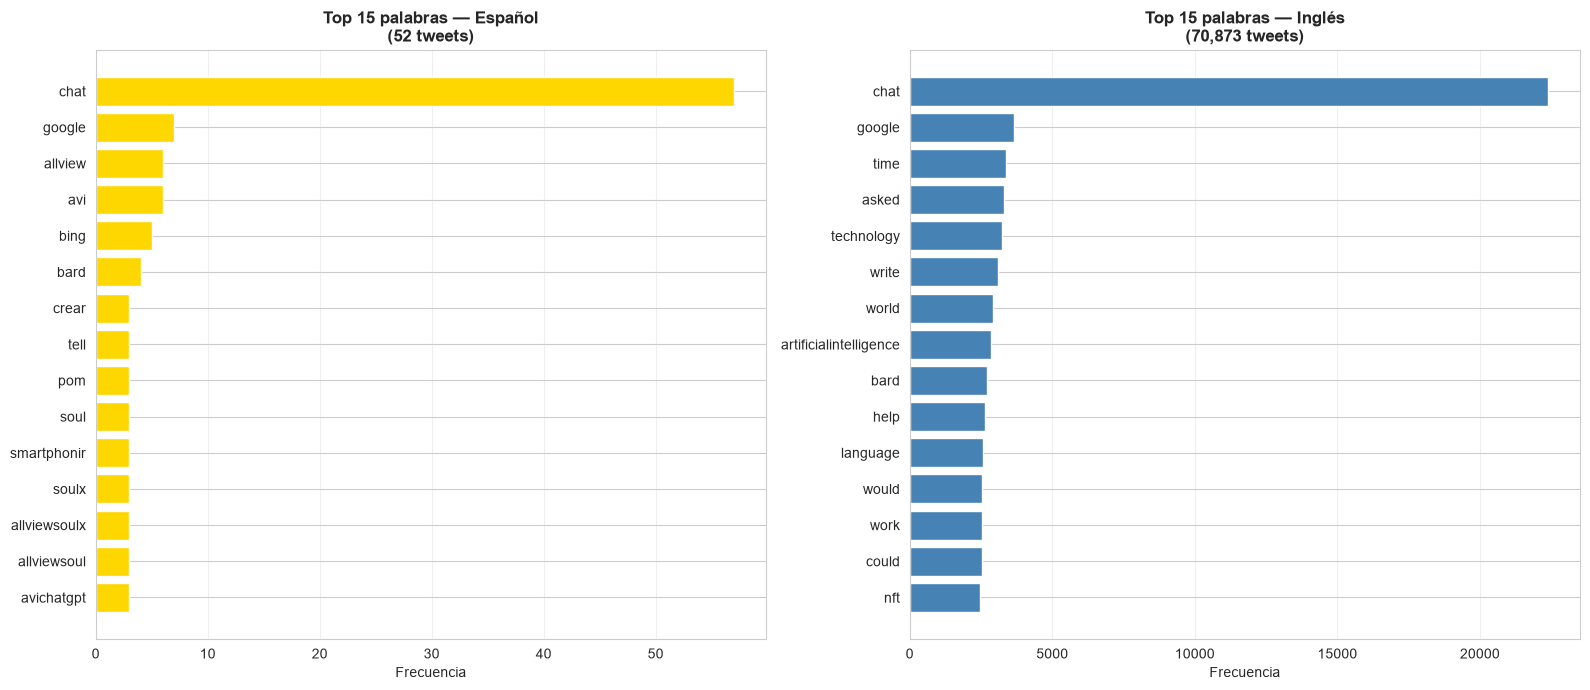


✅ Guardado: outputs/figuras/top_palabras_por_idioma.png


In [14]:
# ============================================
# Top 15 palabras por idioma
# ============================================
print("🌍 Analizando top palabras por idioma...")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, idioma in enumerate(["español", "inglés"]):
    df_idioma = df[df["idioma_est"] == idioma]
    
    if len(df_idioma) == 0:
        continue
    
    palabras = []
    for lemas in df_idioma["lemas"]:
        palabras.extend(lemas)
    
    top_15 = Counter(palabras).most_common(15)
    
    palabras_n = [p[0] for p in top_15][::-1]
    freqs_n = [p[1] for p in top_15][::-1]
    
    color = "gold" if idioma == "español" else "steelblue"
    axes[idx].barh(palabras_n, freqs_n, color=color)
    axes[idx].set_title(
        f"Top 15 palabras — {idioma.capitalize()}\n({len(df_idioma):,} tweets)",
        fontsize=12, fontweight="bold"
    )
    axes[idx].set_xlabel("Frecuencia")
    axes[idx].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_FIGURAS / "top_palabras_por_idioma.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ Guardado: outputs/figuras/top_palabras_por_idioma.png")

In [15]:
# ============================================
# Resumen final y verificación
# ============================================
print("=" * 60)
print("✅ RESUMEN FINAL DEL EDA")
print("=" * 60)

print(f"\n📄 Tweets analizados:    {len(df):,}")
print(f"👥 Usuarios únicos:      {df['username'].nunique():,}")
print(f"📅 Rango temporal:       {df['date'].min().date()} → {df['date'].max().date()}")
print(f"📚 Vocabulario (lemas):  {len(vocab_lemas):,}")

print(f"\n🌍 Distribución por idioma:")
for idioma, count in df["idioma_est"].value_counts().items():
    pct = count / len(df) * 100
    print(f"   {idioma:10s}: {count:>7,} ({pct:5.1f}%)")

# Guardar top palabras para el informe
tabla_top = pd.DataFrame(top_30, columns=["palabra", "frecuencia"])
tabla_top.to_csv(OUTPUTS_FIGURAS.parent / "reportes" / "top_palabras.csv",
                 index=False, encoding="utf-8-sig")
print(f"\n✅ Tabla top palabras guardada")

print(f"\n📂 Figuras generadas en outputs/figuras/:")
for f in sorted(OUTPUTS_FIGURAS.glob("*.png")):
    size_kb = f.stat().st_size / 1024
    print(f"   ✅ {f.name} ({size_kb:.0f} KB)")

print("\n🎯 Siguiente paso: Notebook 04 — NLP análisis de sentimientos")

✅ RESUMEN FINAL DEL EDA

📄 Tweets analizados:    95,958
👥 Usuarios únicos:      59,983
📅 Rango temporal:       2023-03-16 → 2023-03-29
📚 Vocabulario (lemas):  65,132

🌍 Distribución por idioma:
   inglés    :  70,873 ( 73.9%)
   otro      :  25,033 ( 26.1%)
   español   :      52 (  0.1%)

✅ Tabla top palabras guardada

📂 Figuras generadas en outputs/figuras/:
   ✅ distribucion_idiomas.png (35 KB)
   ✅ engagement_distribucion.png (129 KB)
   ✅ top_30_palabras.png (71 KB)
   ✅ top_bigramas.png (70 KB)
   ✅ top_palabras_por_idioma.png (71 KB)
   ✅ top_trigramas.png (67 KB)
   ✅ tweets_por_dia.png (101 KB)
   ✅ wordcloud_chatgpt.png (1072 KB)

🎯 Siguiente paso: Notebook 04 — NLP análisis de sentimientos
